# ANALYTICAL PROBLEM DEFINITION

**Application Domain:**
- Retail – E-Commerce Analytics

**Dataset Selected:**

Superstore Sales Dataset (Kaggle)

URL: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting

- This dataset contains structured retail transaction data including order information, sales, quantity, discounts, shipping modes, and customer segments. Such information suitable for predictive analytics and the task at hand.


**Analytical Problem:**
- E-commerce retailers must estimate future sales and understand factors influencing revenue to optimize pricing, inventory,and promotional strategies.

**Decision Objective:**
- Build a predictive model capable of forecasting product sales based on historical transactional features.

**Target Variable:**
- Sales

**Role of Data-Driven Modeling:**
- Machine learning model will analyze relationships the  between the target variable (sales) and other relevant variables to generate sales predictions.




## Required libraries

In [205]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# PART A

## Dataset load

In [206]:
# Load the  dataset
df = pd.read_csv("Superstore Sales Dataset.csv")

# View first rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Dataset Structure

In [207]:
# Check dataset shape
df.shape

(9800, 18)

In [208]:
# View column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [209]:
# Check data types
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

### Dataset Overview

The dataset contains 9,800 transaction records and 18 variables.

**The dataset includes:**
- Transaction identifiers (Row ID, Order ID)
- Temporal information (Order Date, Ship Date)
- Customer information (Customer ID, Customer Name, Segment)
- Geographic information (Country, City, State, Postal Code, Region)
- Product details (Product ID, Category, Sub-Category, Product Name)
- Target variable: Sales

**Data Types:**
- Numerical variables: Row ID, Postal Code, Sales
- Categorical/text variables: Customer details, product categories, shipping mode, and geographic attributes
- Date variables currently stored as objects (Order Date, Ship Date)

## Check missing values

In [210]:
# Identify missing values in the dataset
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Handling the missing values

In [211]:
# Drop missing values
df = df.dropna()

# Verify missing values are handled
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

## Checking duplicate values

In [212]:
# Check for duplicates
df.duplicated().sum()

# If 0 duplicates, print message
if df.duplicated().sum() == 0:
    print("No duplicate records found.")
    
# If duplicates exist, drop them and print message
else:
    df = df.drop_duplicates()
    print(f"Duplicate records found and removed. Remaining duplicates: {df.duplicated().sum()}")

No duplicate records found.


## Outliers detection

### Visualizing outliers using boxplot

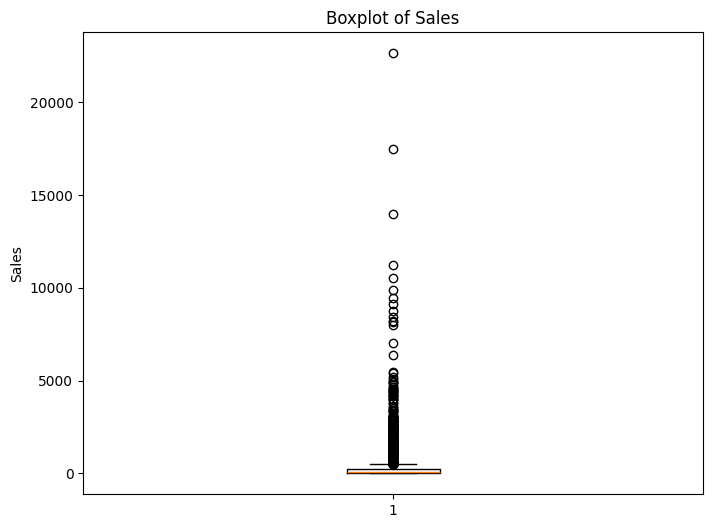

In [213]:
# Check for outliers in the 'Sales' column using boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(df['Sales'])
plt.title('Boxplot of Sales')
plt.ylabel('Sales')
plt.show()

### Printing outliers using IQR method

In [214]:
# Display outliers in the 'Sales' column using IQR method
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"Outliers in 'Sales' column:\n{outliers.shape[0]}")

# Print percentage of outliers in the 'Sales' column
outlier_percentage = (outliers.shape[0] / df.shape[0]) * 100
print(f"Percentage of outliers in 'Sales' column: {outlier_percentage:.2f}%")

Outliers in 'Sales' column:
1141
Percentage of outliers in 'Sales' column: 11.66%


### Handling outliers using winsorization method

In [215]:
# using winsorization method to handle outliers in the 'Sales' column
df['Sales'] = np.where(df['Sales'] < lower_bound, lower_bound, df['Sales'])
df['Sales'] = np.where(df['Sales'] > upper_bound, upper_bound, df['Sales'])

Outliers in the Sales variable are treated using the Winsorization technique. Instead of removing extreme values, Winsorization caps them at calculated lower and upper bounds based on the IQR method.

This approach preserves the dataset size while reducing the influence of extreme values on predictive modeling.

## Basic Exploratory Analysis

### Distribution of 'Sales' after handling outliers

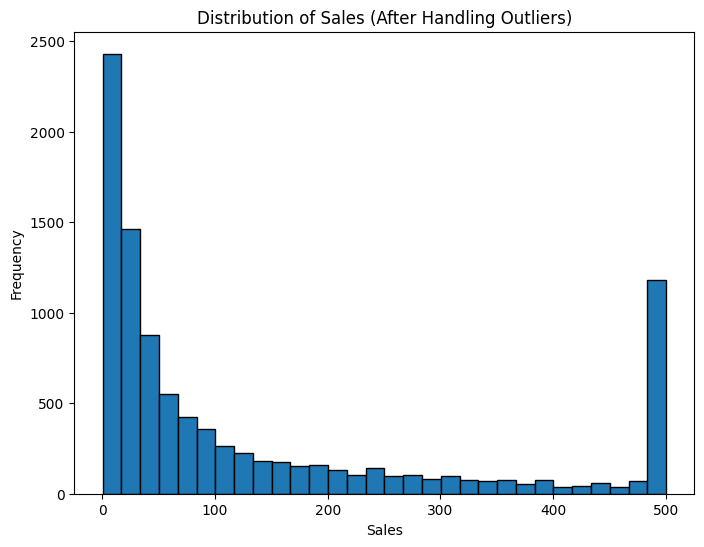

In [216]:
# Plot distribution of 'Sales' column after handling outliers
plt.figure(figsize=(8, 6))
plt.hist(df['Sales'], bins=30, edgecolor='black')
plt.title('Distribution of Sales (After Handling Outliers)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### Sales by product category

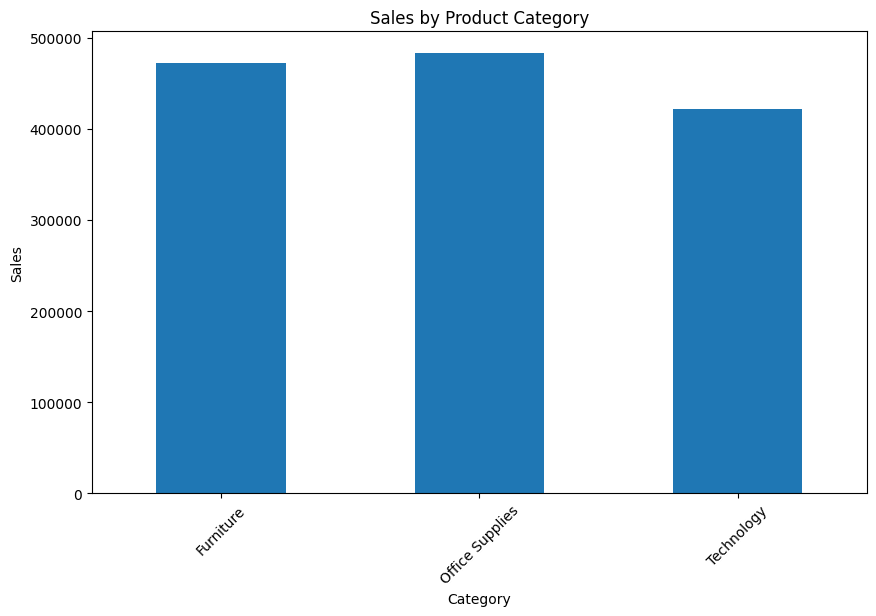

In [217]:
# Plot sales by product category
plt.figure(figsize=(10, 6))
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

### Sales by region

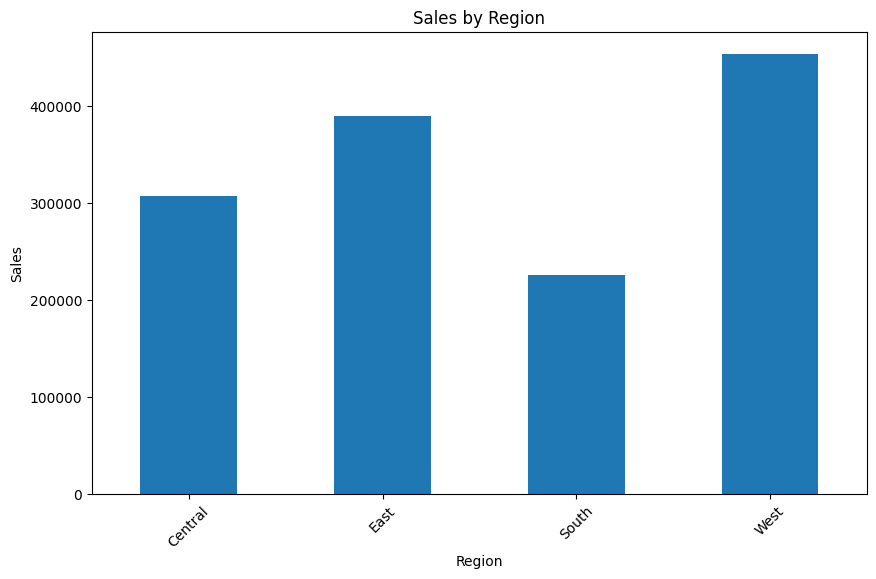

In [218]:
# Plot sales by region
plt.figure(figsize=(10, 6))
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

### Average sales by customer segment

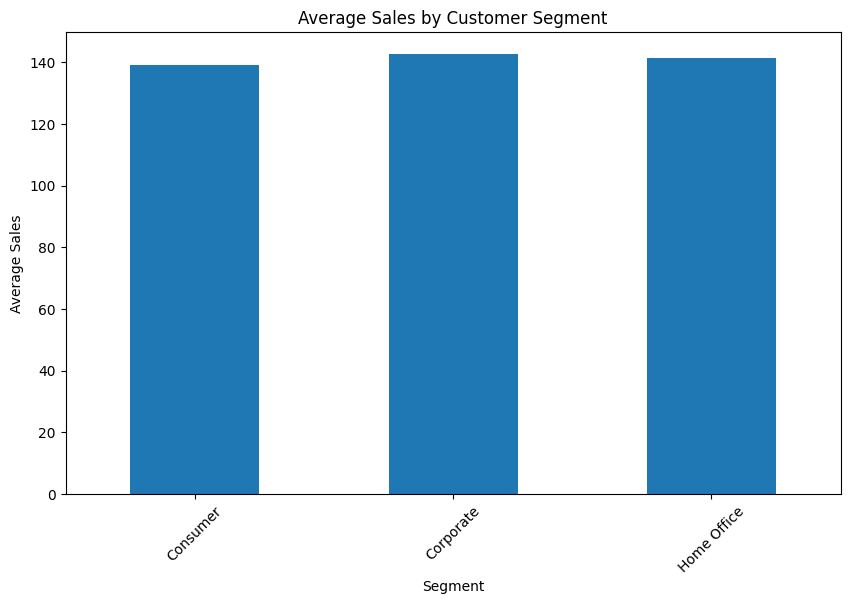

In [219]:
#Plot average sales by customer segment
plt.figure(figsize=(10, 6))
df.groupby("Segment")["Sales"].mean().plot(kind="bar")
plt.title("Average Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

## Saving the cleaned dataset

In [220]:
# Save cleaned dataset to a new CSV file
df.to_csv("Wambede.csv", index=False)

# PART B

In [221]:
# Loading the cleaned dataset
df = pd.read_csv("Wambede.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",500.108
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,500.108
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368


#### Options dataset

To be used for deployment

In [222]:
# Extract only the columns needed for deployment dropdowns
options_df = df[[
    "Region",
    "State",
    "City",
    "Category",
    "Sub-Category",
    "Product Name"
]].drop_duplicates()

# Save file
options_df.to_csv("options_dataset.csv", index=False)

print("Options dataset saved successfully.")

Options dataset saved successfully.


## Feature Engineering

In [223]:
# Convert date columns to datetime format to allow extraction of time patterns such as
# seasonality and ordering trends in retail transactions.
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)


# Extract temporal features from Order Date to capture seasonal purchasing behavior.
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Day"] = df["Order Date"].dt.day



# Calculate shipping duration (days between order and shipment)to represent
# delivery efficiency and logistics speed.
df["Shipping_Duration"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days


# Product Frequency represents how often a product appears
# in the dataset and can indicate product demand or popularity.
df["Product_Frequency"] = (
    df.groupby("Product Name")["Product Name"]
    .transform("count")
)

In [224]:
# View column names to verify new features
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order_Year', 'Order_Month', 'Order_Day',
       'Shipping_Duration', 'Product_Frequency'],
      dtype='object')

## Separating numerical and categorical features

In [225]:
# Target variable
target = 'Sales'

# Numerical variables
numerical_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove target from numerical list
numerical_vars.remove(target)

# Categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Variables:", numerical_vars)
print("Categorical Variables:", categorical_vars)

Numerical Variables: ['Row ID', 'Postal Code', 'Shipping_Duration', 'Product_Frequency']
Categorical Variables: ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


## Variable Selection

### Correlation analysis (numerical variables)

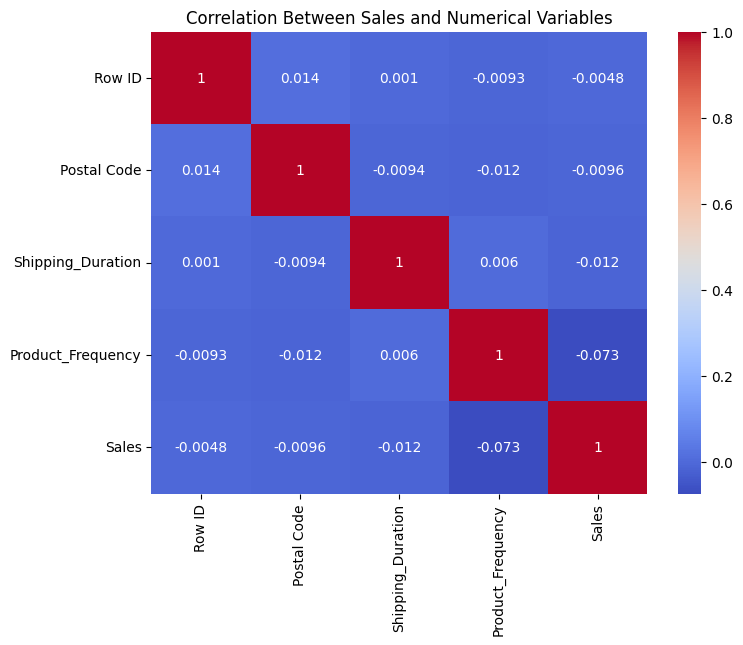

In [226]:
# Correlation matrix for numerical variables using heatmap
plt.figure(figsize=(8,6))

corr_matrix = df[numerical_vars + [target]].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Between Sales and Numerical Variables")
plt.show()

### ANOVA test for numerical features

In [227]:
from sklearn.feature_selection import f_regression

X_num = df[numerical_vars]
y = df[target]

# Apply ANOVA F-test
f_values, p_values = f_regression(X_num, y)

anova_results = pd.DataFrame({
    'Feature': numerical_vars,
    'F_score': f_values,
    'p_value': p_values
})

# Select statistically significant features
selected_numerical = anova_results[anova_results['p_value'] < 0.05]['Feature'].tolist()

print("Selected Numerical Features:")
print(selected_numerical)

Selected Numerical Features:
['Product_Frequency']


### Chi-test for categorical features

In [228]:
# Encoding categorical variables using Label Encoding
from sklearn.preprocessing import LabelEncoder

encoded_df = df.copy()

le = LabelEncoder()

for col in categorical_vars:
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    

# Chi - square test for categorical variables
from sklearn.feature_selection import chi2

# Convert Sales into categories for chi-square
encoded_df['Sales_Category'] = pd.qcut(encoded_df['Sales'], q=4, labels=False)

X_cat = encoded_df[categorical_vars]
y_cat = encoded_df['Sales_Category']

chi_scores, p_values = chi2(X_cat, y_cat)

chi_results = pd.DataFrame({
    'Feature': categorical_vars,
    'Chi_score': chi_scores,
    'p_value': p_values
})

selected_categorical = chi_results[chi_results['p_value'] < 0.05]['Feature'].tolist()

print("Selected Categorical Features:")
print(selected_categorical)

Selected Categorical Features:
['Order ID', 'Customer ID', 'Customer Name', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


### Statistically selected features for modeling

In [229]:
# Statistically Selected Features for Modeling
selected_features = selected_numerical + selected_categorical

print("Statistically Selected Features for Modeling:")
print(selected_features)

Statistically Selected Features for Modeling:
['Product_Frequency', 'Order ID', 'Customer ID', 'Customer Name', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


**Initial statistically selected features:**

['Product_Frequency', 'Order ID', 'Customer ID', 'Customer Name',
'City', 'State', 'Region', 'Product ID', 'Category',
'Sub-Category', 'Product Name']

However, not all selected variables are suitable for predictive modeling. Identifier variables such as Order ID, Customer ID, Customer Name, and Product ID do not contain meaningful predictive information.

These columns are unique identifiers used only for record tracking and do not generalize patterns for machine learning models. Therefore, they are excluded from the modeling dataset.

### Final Selected Features for Modeling

In [230]:
# Final features retained for modeling
model_features = [
    'Product_Frequency',
    'City',
    'State',
    'Region',
    'Category',
    'Sub-Category',
    'Product Name'
]

print("Final Features Used for Modeling:")
print(model_features)

Final Features Used for Modeling:
['Product_Frequency', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name']


**Feature justification**

1. Product_Frequency
- Represents how frequently a product appears in transactions, indicating product demand and popularity. 

2. City, State, Region
- These geographic variables capture regional purchasing patterns and market differences. 

3. Category and Sub-Category
- These variables represent the hierarchical classification of products. Different product groups exhibit different sales patterns and customer demand.

4. Product Name
- This provides detailed product-level granularity, allowing the model to learn which specific products generate higher sales.

## Machine learning model development

### Prepare dataset for modeling

In [231]:
# Target variable
target = "Sales"

# Feature matrix and target vector
X = df[model_features]
y = df[target]


# Encoding categorical variables using one-hot encoding for modeling

# Convert categorical variables into numerical format
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (9789, 2444)


### Train-test split

In [232]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (7831, 2444)
Testing samples: (1958, 2444)


### Training Multiple Models

In [233]:
# Train multiple models and compute metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

n = X_test.shape[0]
p = X_test.shape[1]

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    # Adjusted R2
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    
    # MAPE
    mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Adjusted R2": adj_r2,
        "MAPE (%)": mape
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2,MAPE (%)
0,Linear Regression,56.259621,7608.184987,87.224910,0.729742,2.086025,146.373208
1,Random Forest,54.980461,8325.526138,91.244321,0.704261,2.188422,86.654338
2,Gradient Boosting,93.026879,15282.691379,123.623183,0.457129,3.181518,341.751667


### Selecting the best model

In [234]:
# Sort models by lowest RMSE and highest R2
sorted_results = results_df.sort_values(
    by=['RMSE', 'R2 Score'],
    ascending=[True, False]
)

best_model_name = sorted_results.iloc[0]['Model']

print("Best Performing Model:", best_model_name)

best_model = models[best_model_name]

Best Performing Model: Linear Regression


**Model Selection Justification**

Multiple evaluation metrics are used to compare model performance, including MAE, MSE, RMSE, R², Adjusted R², and MAPE.
- RMSE is particularly useful because it measures prediction error in the same units as the target variable (Sales).
- R² and Adjusted R² indicate how well the model explains the variability in sales values.
- MAE provides the average absolute prediction error, while
- MAPE expresses prediction error as a percentage.

The best model is selected based primarily on the lowest RMSE and highest R², ensuring both accuracy and explanatory power.

### Residual Analysis

To evaluate the distribution of prediction errors.

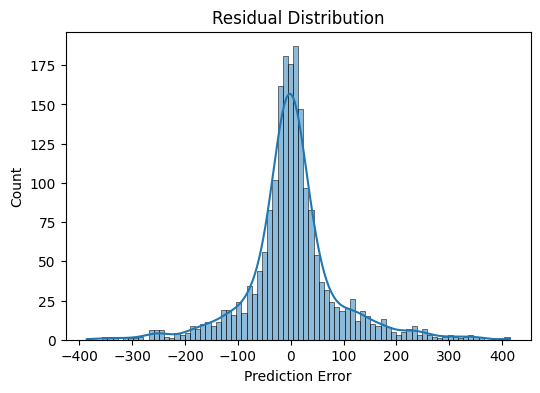

In [235]:
# residual analysis for best model
residuals = y_test - best_model.predict(X_test)

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

**Purpose:**

- Checks if errors are centered around zero

- Helps validate Linear Regression assumptions

### An actual vs predicted sales plot 

It is generated to visually inspect prediction accuracy.

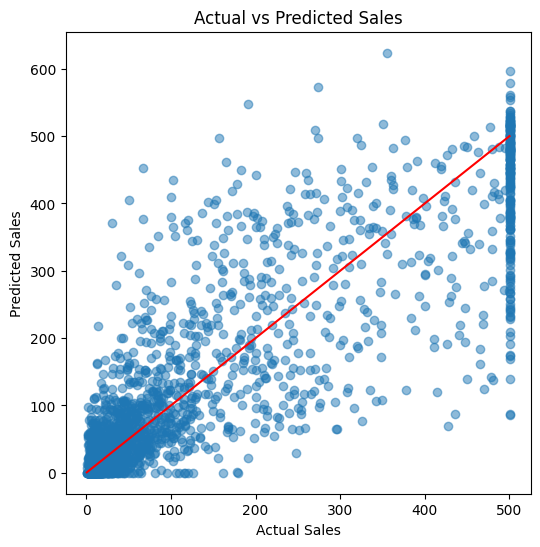

In [236]:
# Actual vs Predicted Sales
best_predictions = best_model.predict(X_test)

best_predictions = np.maximum(best_predictions, 0)


plt.figure(figsize=(6,6))

plt.scatter(y_test, best_predictions, alpha=0.5)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

**Interpretation:**

- Points close to the red line indicate good predictions

### Model coefficient analysis 

Since Linear Regression is the best-performing model, it is used to identify features that influence sales predictions.

In [237]:
# Model Coefficient Analysis (for linear models)
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": best_model.coef_
})

# Display most influential features
coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
1479,Product Name_Hunt BOSTON Model 1606 High-Volum...,455.261751
1277,Product Name_GBC DocuBind P400 Electric Bindin...,448.850201
1489,Product Name_Ibico EPK-21 Electric Binding System,438.323533
1274,Product Name_GBC DocuBind 200 Manual Binding M...,435.563009
1282,Product Name_GBC Ibimaster 500 Manual ProClick...,433.217729
1491,Product Name_Ibico Ibimaster 300 Manual Bindin...,432.391085
1244,Product Name_Fellowes PB500 Electric Punch Pla...,425.875537
1407,Product Name_High Speed Automatic Electric Let...,423.391934
1280,Product Name_GBC DocuBind TL300 Electric Bindi...,422.926060
1279,Product Name_GBC DocuBind TL200 Manual Binding...,417.841354


## Save the model

In [238]:
import joblib

joblib.dump(best_model, "Wambede_best_model.pkl")

print("Model saved as Wambede_best_model.pkl")

Model saved as Wambede_best_model.pkl


### Save Model Features

This ensures that the deployment app uses the same feature structure used during training.

In [239]:
joblib.dump(X_encoded.columns.tolist(), "model_features.pkl")

print("Feature structure saved successfully.")

Feature structure saved successfully.


## Generate Predictions

### Load Saved Model and Feature Structure

In [240]:
import joblib

# Load trained model
best_model = joblib.load("Wambede_best_model.pkl")

# Load model feature structure
model_features = joblib.load("model_features.pkl")

print("Model and feature structure loaded successfully.")

Model and feature structure loaded successfully.


### Prepare dataset again (same preprocessing)

The model must receive the exact same features used during training.

In [241]:
# Features used during modeling
features = [
    'Product_Frequency',
    'City',
    'State',
    'Region',
    'Category',
    'Sub-Category',
    'Product Name'
]

X = df[features]
y = df["Sales"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

### Align dataset with training feature structure

This ensures prediction works even if some encoded columns are missing

In [242]:
# Align features with training model
X_encoded = X_encoded.reindex(columns=model_features, fill_value=0)

### Create hold-out subset from original data

In [243]:
from sklearn.model_selection import train_test_split

X_train_holdout, X_holdout, y_train_holdout, y_holdout = train_test_split(
    X_encoded,
    y,
    test_size=0.1,
    random_state=42
)

print("Hold-out dataset size:", X_holdout.shape)

Hold-out dataset size: (979, 2444)


- The hold-out subset simulates new unseen data and allows evaluation of the model's generalization performance.

### Generate predictions

In [244]:
# Generate predictions on hold-out set
holdout_predictions = best_model.predict(X_holdout)

# Ensure predictions are non-negative
holdout_predictions = np.clip(holdout_predictions, a_min=0, a_max=None)

predictions_df = pd.DataFrame({
    "Actual Sales": y_holdout,
    "Predicted Sales": holdout_predictions
})

predictions_df.head()

,Actual Sales,Predicted Sales
8959,273.960,497.645170
7136,62.880,80.560183
4708,11.680,35.827060
6202,7.712,0.000000
6899,500.108,480.181237


- The predictions have been generated on a hold-out subset derived from the original dataset.

## Save predictions

In [245]:
# Save predictions to CSV
predictions_df.to_csv("Wambede_predictions.csv", index=False)

print("Predictions saved as Wambede_predictions.csv")

Predictions saved as Wambede_predictions.csv


# PART C

## TEXT DATASET DESCRIPTION


**Dataset:**

Amazon Fine Food Reviews

URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

The Amazon Fine Food Reviews dataset contains customer feedback on food products sold through the Amazon e-commerce platform. The dataset includes attributes such as review scores, review summaries, full review text, product identifiers, and timestamps.


The dataset was selected because it provides rich textual information describing customer experiences, satisfaction, and opinions about products. This makes it suitable for applying Natural Language Processing (NLP) techniques.

**Objective:**

Understand customer sentiment from product reviews and extract insights that can complement sales forecasting by revealing customer satisfaction, product perception, and demand drivers.

**Relation to the Analytical Problem:**

The overall objective of the project is to analyze factors that influence product sales in an e-commerce environment. While the structured dataset supports sales prediction using transaction data, the textual dataset provides insight into customer sentiment and product perception.

Customer reviews often influence purchasing decisions and can explain patterns observed in sales data. By analyzing review sentiment and frequently mentioned keywords, the analysis identifies product attributes that contribute to positive or negative customer experiences.

Therefore, combining structured sales data with textual review analysis provides a more comprehensive understanding of product performance in the retail e-commerce domain.

## Load the dataset

In [246]:
# Load Amazon Fine Food Reviews dataset
import pandas as pd

reviews_df = pd.read_csv("Amazon Fine Food Reviews.csv")

reviews_df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### Dataset Inspection

In [247]:
# Dataset Inspection
reviews_df.shape
reviews_df.columns

# Display key columns to understand review structure
reviews_df[['Score','Summary','Text']].head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


### Text Preprocessing

In [248]:
import re

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    
    return text

reviews_df['clean_text'] = reviews_df['Text'].apply(clean_text)

### Tokenization and Stopword Removal

In [249]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

stop_words = set(stopwords.words('english'))

def preprocess(text):
    
    tokens = word_tokenize(text)
    
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

reviews_df['processed_text'] = reviews_df['clean_text'].apply(preprocess)

### Sentiment Label Creation

Converting review scores into sentiment categories

In [250]:
# Create sentiment labels based on review scores
def sentiment_label(score):
    
    if score <= 2:
        return "Negative"
    
    elif score == 3:
        return "Neutral"
    
    else:
        return "Positive"

reviews_df['Sentiment'] = reviews_df['Score'].apply(sentiment_label)

reviews_df[['Score','Sentiment']].head()

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive


## Visualizations

### Sentiment Distribution

Shows overall customer satisfaction levels.

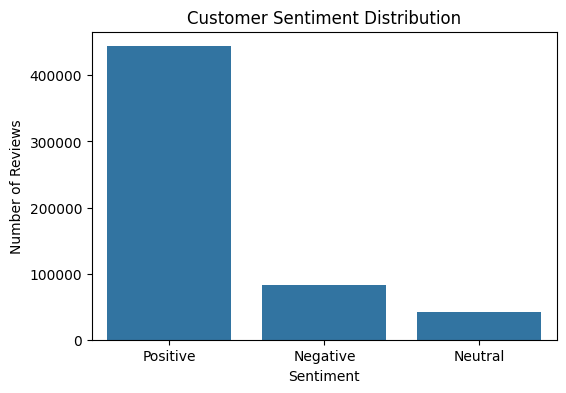

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Sentiment', data=reviews_df)

plt.title("Customer Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

# Save the plot as an image file
plt.savefig("Customer Sentiment Distribution.png", bbox_inches="tight")

plt.show()


### Review lenght Distribution

Shows how detailed customers are in their reviews.

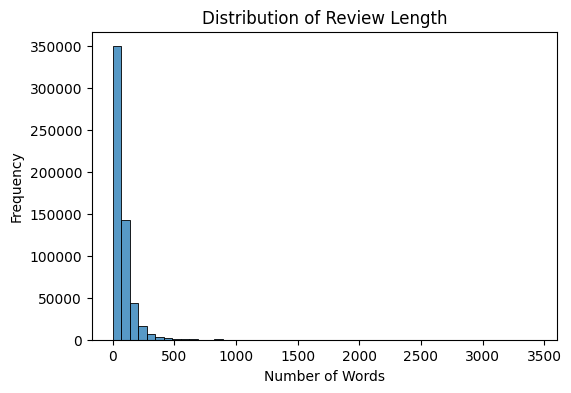

In [262]:
reviews_df['review_length'] = reviews_df['Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))

sns.histplot(reviews_df['review_length'], bins=50)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

# Save the plot as an image file
plt.savefig("Distribution of Review Length.png", bbox_inches="tight")

plt.show()

- Visualizations of sentiment distribution and review length provide insights into customer satisfaction patterns and review behavior.


### Word Cloud

Shows the most frequent words in customer reviews

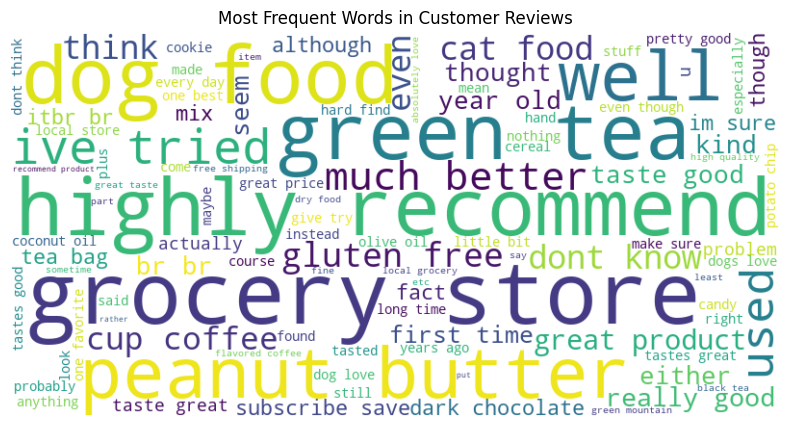

In [263]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all processed review text
text_corpus = " ".join(reviews_df['processed_text'].dropna())

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(text_corpus)

# Display word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

plt.title("Most Frequent Words in Customer Reviews")

# Save the plot as an image file
plt.savefig("Most Frequent Words in Customer Reviews.png", bbox_inches="tight")

plt.show()

## TF-IDF Feature Extraction

TF-IDF feature extraction is to be used to convert textual data into numerical representations, allowing identification of important keywords frequently mentioned by customers.

In [254]:
# TF-IDF feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english'
)

X_text = tfidf.fit_transform(reviews_df['processed_text'])

print("TF-IDF matrix shape:", X_text.shape)

TF-IDF matrix shape: (568454, 1000)


### Extract important words

This identifies frequently discussed product aspects

In [255]:
# Top keywords in reviews based on average TF-IDF scores
import numpy as np

feature_names = tfidf.get_feature_names_out()

tfidf_scores = np.mean(X_text.toarray(), axis=0)

keywords = pd.DataFrame({
    "Word": feature_names,
    "Importance": tfidf_scores
})

keywords.sort_values(by="Importance", ascending=False).head(20)

,Word,Importance
474,like,0.036897
352,good,0.034664
163,coffee,0.034334
360,great,0.033975
91,br,0.032860
677,product,0.029742
869,taste,0.029692
874,tea,0.029254
498,love,0.028267
312,flavor,0.026861


## NLP Analysis — Positive review keywords

Top Words in Positive Reviews show what customers like most about products.

In [256]:
positive_reviews = reviews_df[reviews_df['Sentiment'] == 'Positive']

tfidf_pos = TfidfVectorizer(
    max_features=500,
    stop_words='english'
)

X_pos = tfidf_pos.fit_transform(positive_reviews['processed_text'])

words = tfidf_pos.get_feature_names_out()

scores = np.mean(X_pos.toarray(), axis=0)

positive_keywords = pd.DataFrame({
    "Word": words,
    "Score": scores
})

positive_keywords.sort_values(by="Score", ascending=False).head(15)

,Word,Score
200,great,0.043835
196,good,0.041622
258,like,0.040934
85,coffee,0.038585
47,br,0.036990
272,love,0.036062
441,tea,0.035260
353,product,0.033087
436,taste,0.032173
169,flavor,0.030910


- The NLP analysis highlights key product attributes and customer perceptions that may influence product demand and sales trends.

## Reuse Demonstration

### Load Dataset

In [257]:
import joblib
import pandas as pd
import numpy as np

# Load trained model
loaded_model = joblib.load("Wambede_best_model.pkl")

# Load feature structure used during training
model_features = joblib.load("model_features.pkl")

print("Model and feature structure loaded successfully.")

Model and feature structure loaded successfully.


### Create Example Input Data

This simulates new unseen retail data for inference

In [258]:
sample_data = pd.DataFrame({
    "Product_Frequency": [12, 5],
    "City": ["New York", "Los Angeles"],
    "State": ["New York", "California"],
    "Region": ["East", "West"],
    "Category": ["Snack Foods", "Beverages"],
    "Sub-Category": ["Chips", "Soft Drinks"],
    "Product Name": ["Potato Chips", "Cola Drink"]
})

sample_data

,Product_Frequency,City,State,Region,Category,Sub-Category,Product Name
0,12,New York,New York,East,Snack Foods,Chips,Potato Chips
1,5,Los Angeles,California,West,Beverages,Soft Drinks,Cola Drink


### Encode the Sample Data

The same encoding used during training has to be applied

In [259]:
sample_encoded = pd.get_dummies(sample_data, drop_first=True)

# Align with model training feature structure
sample_encoded = sample_encoded.reindex(columns=model_features, fill_value=0)

sample_encoded.head()

,Product_Frequency,City_Abilene,City_Akron,City_Albuquerque,City_Alexandria,City_Allen,City_Allentown,City_Altoona,City_Amarillo,City_Anaheim,...,Product Name_Zebra ZM400 Thermal Label Printer,Product Name_Zebra Zazzle Fluorescent Highlighters,Product Name_Zipper Ring Binder Pockets,Product Name_i.Sound Portable Power - 8000 mAh,Product Name_iHome FM Clock Radio with Lightning Dock,"Product Name_iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",Product Name_iOttie HLCRIO102 Car Mount,Product Name_iOttie XL Car Mount,Product Name_invisibleSHIELD by ZAGG Smudge-Free Screen Protector,Product Name_netTALK DUO VoIP Telephone Service
0,12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Generate Example Predictions

In [260]:
predicted_sales = loaded_model.predict(sample_encoded)

# Ensure predictions remain non-negative
predicted_sales = np.clip(predicted_sales, a_min=0, a_max=None)

inference_results = sample_data.copy()
inference_results["Predicted Sales"] = predicted_sales

inference_results

# Save inference results to CSV
inference_results.to_csv("sample_inference_results.csv", index=False)

**Model Reuse and Inference**

- The trained regression model stored as "Wambede_best_model.pkl" is loaded and reused to generate predictions on new sample data.

- Example input data is created to simulate unseen product transactions in an e-commerce environment.

- The input data is encoded and aligned with the feature structure used during training to ensure compatibility with the model.

- The model then generates predicted sales values, demonstrating how the trained model can be reused to produce real-time predictions in an operational system.